## Homework 2: Company Fundamental Deep Dive - Group 3(United Kingdom) 

**Course:** Big Data Analytics  
**Professor:** Giovanni Morana  
**Student:** Carmen Padova  
**Student ID:** 100003559(4) → Group 3 (United Kingdom) 

In [230]:
# ==================================================================================
# PRELIMINARY SETUP — Libraries, Dataset Loading, Geographic Filtering and Screening
# ==================================================================================
# Before selecting the company, I inspect the companies available in my assigned
# geographic group. This preliminary screening helps identify a firm with enough
# market size, profitability and growth to make the peer comparison meaningful.

# 1. LIBRARY IMPORTS
# pandas and numpy are used for data handling and cleaning.
# matplotlib and seaborn are used to produce the charts required by the homework.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. PLOT STYLE SETTINGS
# The whitegrid theme improves chart readability in a notebook/report format.
sns.set_theme(style="whitegrid")

# 3. DATASET LOADING
# The dataset is loaded once at the beginning and reused in the following steps.
df_raw = pd.read_csv("data/Symbol_Info_extended.csv")

# 4. GEOGRAPHIC FILTERING
# My Student ID ends in 4, so according to the assignment I belong to Group 3:
# United Kingdom. Therefore, the selected company must come from this country.
df_uk = df_raw[df_raw["country"] == "United Kingdom"].copy()

# 5. RESULTS VERIFICATION
# These counts verify that the original dataset was loaded correctly and that
# the UK filtering produced the expected working pool for company selection.
print(f"Total rows in the original dataset: {len(df_raw)}")
print(f"Available companies in Group 3 (United Kingdom): {len(df_uk)}\n")

# 6. VISUAL INSPECTION FOR COMPANY SELECTION
# I display the most relevant variables for the initial screening: company size,
# profitability, valuation, growth and leverage.
screening_columns = [
    "symbol", "company_name", "sector", "industry", "market_cap",
    "profit_margins", "return_on_equity", "pe_trailing",
    "revenue_growth", "debt_to_equity"
]

df_uk_screening = df_uk[screening_columns].sort_values("market_cap", ascending=False)

# Printing as text keeps the output stable and avoids a very large HTML table.
print("UK companies:")
print(df_uk_screening.to_string(index=False))


Total rows in the original dataset: 3070
Available companies in Group 3 (United Kingdom): 24

UK companies:
symbol                                company_name             sector                                 industry   market_cap  profit_margins  return_on_equity  pe_trailing  revenue_growth  debt_to_equity
   ARM                            Arm Holdings plc         Technology                           Semiconductors 3.261262e+11         0.18374           0.11954   356.406980           0.201           5.214
   AZN                             AstraZeneca PLC         Healthcare             Drug Manufacturers - General 2.900551e+11         0.17189           0.23483    28.167170           0.125          71.815
   LIN                                   Linde plc    Basic Materials                      Specialty Chemicals 2.393017e+11         0.20436           0.18229    34.367863           0.082          65.642
  CCEP          Coca-Cola Europacific Partners PLC Consumer Defensive           

## **Step 0 - Select a Company** 

In [231]:
# =========================================================================
# STEP 0 — TARGET COMPANY SELECTION AND JUSTIFICATION
# =========================================================================
# Target Company Selected: AstraZeneca PLC (Symbol: AZN)
#
# I selected AstraZeneca (AZN) for this analysis. During the preliminary
# screening of UK companies, AstraZeneca stood out because of its combination
# of large size, profitability and growth.
#
# With a market capitalization of approximately $290 billion, it is one of the
# largest companies in the UK group. At the same time, it reports strong
# profit margins (17.2%) and return on equity (23.5%), indicating solid
# profitability. In addition, revenue growth of 12.5% suggests that the
# company is still expanding despite its already large scale.
#
# These characteristics make AstraZeneca a suitable company for evaluating
# profitability, valuation, growth and financial strength throughout the
# following analysis.

target_symbol = "AZN"
df_target = df_uk[df_uk["symbol"] == target_symbol].copy()

# RESULTS VERIFICATION
# Confirm that the selected company is present in the assigned geographic group.
print(
    f"Target company successfully isolated: "
    f"{df_target['company_name'].values[0]} ({target_symbol})"
)

# TARGET DATA INSPECTION
# Display the main financial variables before proceeding to data cleaning.
df_target[[
    "symbol",
    "company_name",
    "industry",
    "market_cap",
    "profit_margins",
    "return_on_assets",
    "return_on_equity",
    "pe_trailing",
    "price_to_book",
    "revenue_growth",
    "debt_to_equity",
    "free_cashflow"
]]

Target company successfully isolated: AstraZeneca PLC (AZN)


,symbol,company_name,industry,market_cap,profit_margins,return_on_assets,return_on_equity,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
300,AZN,AstraZeneca PLC,Drug Manufacturers - General,2.900551e+11,0.17189,0.08487,0.23483,28.16717,6.120693,0.125,71.815,6.558875e+09


## **Step 1 - Data Preparation** 

In [232]:
# =========================================================================
# STEP 1 — DATA PREPARATION & CLEANING
# =========================================================================

# --- 1. SELECTION OF REQUIRED VARIABLES ---
# Define the list of variables explicitly required by the homework.

# Identification and peer-selection variables
id_vars = [
    "symbol",
    "company_name",
    "sector",
    "industry",
    "country",
    "market_cap"
]

# Financial variables for the company deep-dive analysis
fin_vars = [
    "return_on_assets",
    "return_on_equity",
    "profit_margins",
    "pe_trailing",
    "price_to_book",
    "revenue_growth",
    "debt_to_equity",
    "free_cashflow"
]

# Create a working DataFrame containing only the variables required
# for the analysis, while preserving the original dataset unchanged.
df = df_raw[id_vars + fin_vars].copy()


# --- 2. APPLYING CLEANING RULES ---

# Rule (1): Replace infinite values (inf) with NaN.
# Infinite values can result from divisions by zero (e.g., zero revenue
# or zero equity) and are not valid observations.
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Rule (2): Remove companies with non-positive market capitalization.
# A market_cap <= 0 is considered a data-quality issue and should not
# be included in peer-group selection.
df = df[df["market_cap"] > 0].copy()

# Rule (3): Handle invalid valuation multiples.
# Negative or zero P/E and P/B ratios are not comparable with positive
# valuation multiples and would distort valuation charts. The assignment
# requires setting these observations to NaN.
df.loc[df["pe_trailing"] <= 0, "pe_trailing"] = np.nan
df.loc[df["price_to_book"] <= 0, "price_to_book"] = np.nan


# --- 3. FINAL DATA VERIFICATION ---
# Print a quick summary to confirm the correct execution of the cleaning process.
print("Working DataFrame successfully created and cleaned.")
print(f"Total number of companies available for analysis: {len(df)}")

# Display the first rows of the cleaned dataset.
df.head()

Working DataFrame successfully created and cleaned.
Total number of companies available for analysis: 2970


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,NaN,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08


## **Step 2 - Build Peer Groups** 

In [151]:
# =========================================================================
# STEP 2 — PEER GROUPS SELECTION (DEFINITIVE & LITERAL VERSION)
# =========================================================================

# --- 1. REQUIRED PRELIMINARY SETUP ---
# General Rule: If company_name is missing, fallback to the stock symbol as the label
df["display_name"] = df["company_name"].fillna(df["symbol"])

# Extract AstraZeneca's (Target) row as a clean baseline profile
company = df[df["symbol"] == "AZN"].iloc[0]


# --- 2. GROUP A: SAME INDUSTRY ---
# Filter companies belonging to the same industry using the target company profile
pool_A = df[df["industry"] == company["industry"]]

# Sort by market capitalization descending and select the top 10
# ASSIGNMENT NOTE: If pool_A contains fewer than 10 companies, .head(10) automatically retains all of them.
df_A = pool_A.sort_values(
    by="market_cap",
    ascending=False
).head(10).copy()

# Conditional Rule: If AstraZeneca is not in the top 10, append it manually
if "AZN" not in df_A["symbol"].values:

    target_row_A = pool_A[pool_A["symbol"] == "AZN"]

    df_A = pd.concat([
        df_A,
        target_row_A
    ])

    df_A = df_A.sort_values(
        by="market_cap",
        ascending=False
    )


# --- 3. GROUP B: SAME GEOGRAPHIC GROUP (UK) ---
# Select all companies located in the assigned geographic group (United Kingdom)
pool_B = df[df["country"] == "United Kingdom"]

# Sort by market capitalization descending and select the top 10
# ASSIGNMENT NOTE: If pool_B contains fewer than 10 companies, .head(10) automatically retains all of them.
df_B = pool_B.sort_values(
    by="market_cap",
    ascending=False
).head(10).copy()

# Conditional Rule: If AstraZeneca is not in the top 10, append it manually
if "AZN" not in df_B["symbol"].values:

    target_row_B = pool_B[pool_B["symbol"] == "AZN"]

    df_B = pd.concat([
        df_B,
        target_row_B
    ])

    df_B = df_B.sort_values(
        by="market_cap",
        ascending=False
    )


# --- 4. GROUP C: CLOSEST MARKET CAPITALIZATION ---
# Create an isolated copy to protect the main dataset from temporary columns
df_pool_C = df.copy()

# Calculate the absolute market cap distance relative to AstraZeneca
df_pool_C["mcap_distance"] = (
    df_pool_C["market_cap"] - company["market_cap"]
).abs()

# Sort by market cap distance and retain the 10 closest companies
df_C = df_pool_C.sort_values(
    by="mcap_distance",
    ascending=True
).head(10).copy()


# --- 5. PREPARE CLEAN TABLES FOR DISPLAY ---
# Define the standard columns to display
view_columns = ["symbol", "display_name", "market_cap"]

# Reset indices and create a clean ranking starting from 1
table_A = df_A[view_columns].reset_index(drop=True)
table_A.index = range(1, len(table_A) + 1)

table_B = df_B[view_columns].reset_index(drop=True)
table_B.index = range(1, len(table_B) + 1)

table_C = df_C[view_columns + ["mcap_distance"]].reset_index(drop=True)
table_C.index = range(1, len(table_C) + 1)


# --- 6. DISPLAY TABLES ---

print("GROUP A: SAME INDUSTRY (Sorted by Market Cap Descending)")
display(table_A)

print("\nGROUP B: SAME UK GEOGRAPHY (Sorted by Market Cap Descending)")
display(table_B)

print("\nGROUP C: SORTED BY MARKET CAP DISTANCE (The 10 Closest Peers)")
display(table_C)

GROUP A: SAME INDUSTRY (Sorted by Market Cap Descending)


,symbol,display_name,market_cap
1,LLY,Eli Lilly and Company,9.497046e+11
2,JNJ,Johnson & Johnson,5.641072e+11
3,ABBV,AbbVie Inc.,3.810972e+11
4,MRK,"Merck & Co., Inc.",3.023312e+11
5,AZN,AstraZeneca PLC,2.900551e+11
6,AMGN,Amgen Inc.,1.831230e+11
7,GILD,"Gilead Sciences, Inc.",1.668173e+11
8,PFE,Pfizer Inc.,1.476156e+11
9,BMY,Bristol-Myers Squibb Company,1.214216e+11
10,BIIB,Biogen Inc.,2.860617e+10



GROUP B: SAME UK GEOGRAPHY (Sorted by Market Cap Descending)


,symbol,display_name,market_cap
1,ARM,Arm Holdings plc,3.261262e+11
2,AZN,AstraZeneca PLC,2.900551e+11
3,LIN,Linde plc,2.393017e+11
4,CCEP,Coca-Cola Europacific Partners PLC,4.167418e+10
5,FTI,TechnipFMC plc,2.830385e+10
6,NVT,nVent Electric plc,2.662889e+10
7,WTW,Willis Towers Watson Public Limited Company,2.431091e+10
8,LYB,LyondellBasell Industries N.V.,2.250455e+10
9,ROIV,Roivant Sciences Ltd.,2.154934e+10
10,WIZEY,Wise Group PLC,1.449383e+10



GROUP C: SORTED BY MARKET CAP DISTANCE (The 10 Closest Peers)


,symbol,display_name,market_cap,mcap_distance
1,AZN,AstraZeneca PLC,2.900551e+11,0.000000e+00
2,GS,"The Goldman Sachs Group, Inc.",2.940427e+11,3.987603e+09
3,PM,Philip Morris International Inc.,2.945520e+11,4.496916e+09
4,TXN,Texas Instruments Incorporated,2.814098e+11,8.645345e+09
5,GEV,GE Vernova Inc.,2.791302e+11,1.092492e+10
6,MRK,"Merck & Co., Inc.",3.023312e+11,1.227611e+10
7,HD,"The Home Depot, Inc.",3.118264e+11,2.177126e+10
8,RY,Royal Bank of Canada,2.637949e+11,2.626024e+10
9,GE,GE Aerospace,3.164162e+11,2.636107e+10
10,MS,Morgan Stanley,3.170816e+11,2.702646e+10


## **Step 3 - Business Question 1: Is the Company Profitable?** 

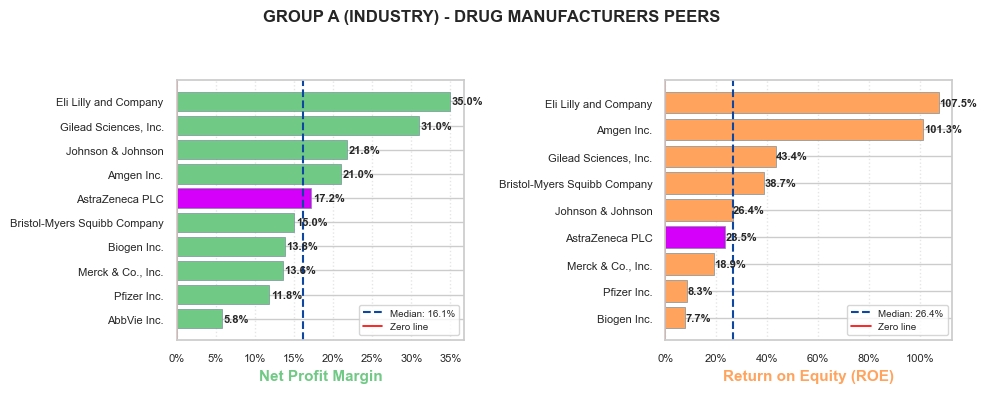

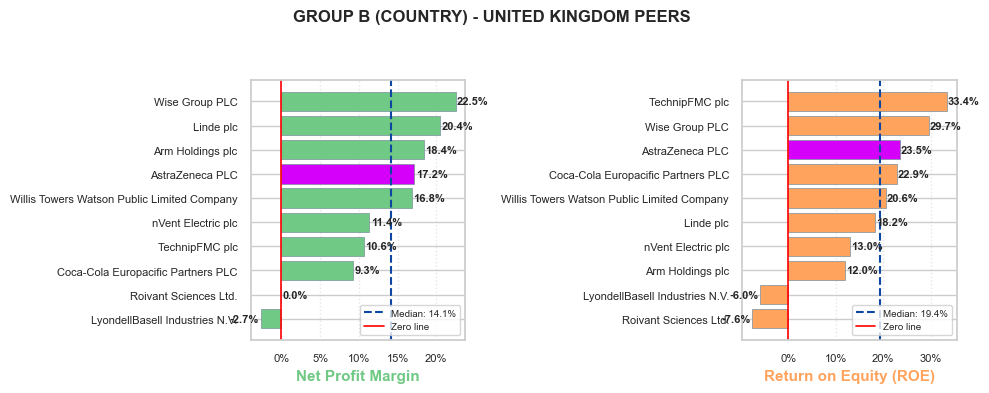

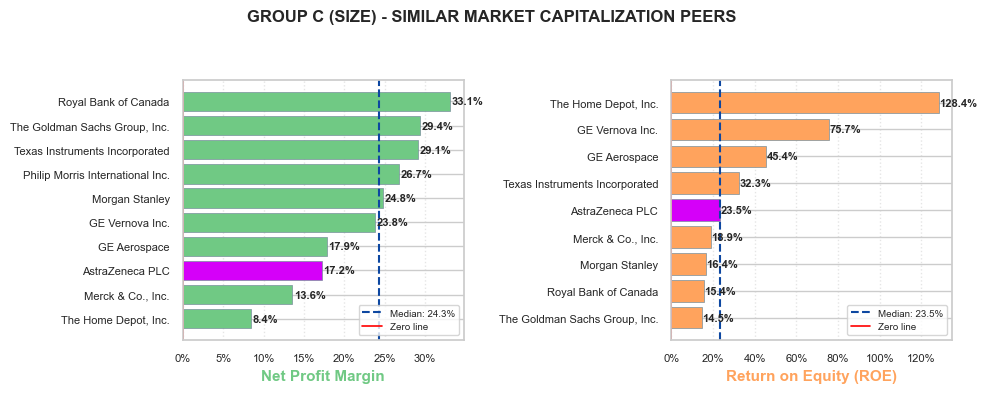

In [233]:
# =========================================================================
# STEP 3 — PROFITABILITY ANALYSIS
# =========================================================================
# Profitability is evaluated using profit_margins and return_on_equity.
# Missing values are removed only for the metric currently being plotted,
# as required by the assignment.


def plot_profitability_side_by_side(data, group_title):
    """Plot profit margin and ROE for one peer group."""

    metrics = [
        ("profit_margins", "Net Profit Margin", "#70C984"),
        ("return_on_equity", "Return on Equity (ROE)", "#FFA35D"),
    ]

    target_color = "#D500F9"   # The selected company is highlighted consistently.
    median_color = "#0D47A1"   # Median line provides a robust peer benchmark.
    zero_color = "#FF0000"     # Zero line is important, especially for ROE.

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor="white")

    for ax, (metric, label, peer_color) in zip(axes, metrics):

        # Remove missing values only for the metric currently being analyzed.
        plot_data = data.dropna(subset=[metric]).sort_values(metric)

        # Highlight the selected company and use a common color for peers.
        colors = [
            target_color if symbol == target_symbol else peer_color
            for symbol in plot_data["symbol"]
        ]

        bars = ax.barh(
            plot_data["display_name"],
            plot_data[metric],
            color=colors,
            edgecolor="#78909C",
            linewidth=0.5
        )

        # Add percentage labels so the chart can be interpreted without
        # referring back to the data table.
        for bar in bars:
            value = bar.get_width()

            # Position labels correctly for both positive and negative values.
            offset = 0.002 if value >= 0 else -0.002
            ha = "left" if value >= 0 else "right"

            ax.text(
                value + offset,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1%}",
                va="center",
                ha=ha,
                fontsize=8,
                fontweight="bold"
            )

        # Add peer median and zero reference line.
        median = plot_data[metric].median()

        ax.axvline(
            median,
            color=median_color,
            linestyle="--",
            linewidth=1.5,
            label=f"Median: {median:.1%}"
        )

        ax.axvline(
            0,
            color=zero_color,
            linewidth=1.2,
            label="Zero line"
        )

        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:.0%}")
        )

        ax.grid(axis="x", linestyle=":", alpha=0.5)
        ax.tick_params(axis="both", labelsize=8)
        ax.legend(fontsize=7, loc="lower right")

        ax.set_xlabel(
            label,
            fontsize=11,
            fontweight="bold",
            color=peer_color
        )

    plt.suptitle(
        group_title.upper(),
        fontsize=12,
        fontweight="bold",
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# -------------------------------------------------------------------------
# PROFITABILITY COMPARISON ACROSS PEER GROUPS
# -------------------------------------------------------------------------
# One chart per peer group, with both profitability metrics shown side by side.

plot_profitability_side_by_side(
    df_A,
    "Group A (Industry) - Drug Manufacturers Peers"
)

plot_profitability_side_by_side(
    df_B,
    "Group B (Country) - United Kingdom Peers"
)

plot_profitability_side_by_side(
    df_C,
    "Group C (Size) - Similar Market Capitalization Peers"
)

## Interpretation

### Profit Margins

AstraZeneca reports **profit margins of 17.2%**.

* **Above** the **Industry median (16.1%)**
* **Above** the **UK median (14.1%)**
* **Below** the **Similar Market Cap median (24.3%)**

According to the interpretative ranges, profit margins above **10%** represent a **strong signal**. Therefore, AstraZeneca demonstrates strong profitability in absolute terms. However, profitability levels above 20% are common among leading pharmaceutical companies, meaning that AstraZeneca's margins are solid but not among the highest within its industry.

Relative to its peers, AstraZeneca performs better than the typical Industry and UK company, although several pharmaceutical peers such as Eli Lilly, Gilead Sciences, Johnson & Johnson and Amgen report higher profit margins.

---

### Return on Equity (ROE)

AstraZeneca reports a **ROE of 23.5%**.

* **Below** the **Industry median (26.4%)**
* **Above** the **UK median (19.4%)**
* **Approximately equal to** the **Similar Market Cap median (23.5%)**

According to the interpretative ranges, a ROE above **15%** represents a **strong signal**. AstraZeneca therefore generates strong returns for shareholders in absolute terms. Although its ROE is slightly below the Industry median, it remains above the UK median and broadly in line with companies of similar size.

Relative to its peers, AstraZeneca is not among the top performers, but it remains positioned around the middle-to-upper part of the peer-group distribution.

---

### Overall Profitability

Overall, AstraZeneca shows **strong profitability**. Both profit margins (**17.2%**) and ROE (**23.5%**) fall within the strong range according to the interpretative benchmarks.

Compared with its peers, AstraZeneca performs above the median in most comparisons and demonstrates solid profitability across different peer groups. While it does not reach the exceptionally high levels reported by some industry leaders such as Eli Lilly, it consistently performs around or above the typical peer.

The two metrics are broadly consistent and suggest that AstraZeneca is able to generate profits efficiently while also providing attractive returns to shareholders. Therefore, AstraZeneca's profitability profile can be considered **strong overall**, although it is not among the strongest performers within its industry.

##
##
##
## **Step 4 - Business Question 2: Is the Company Expensive or Cheap?**

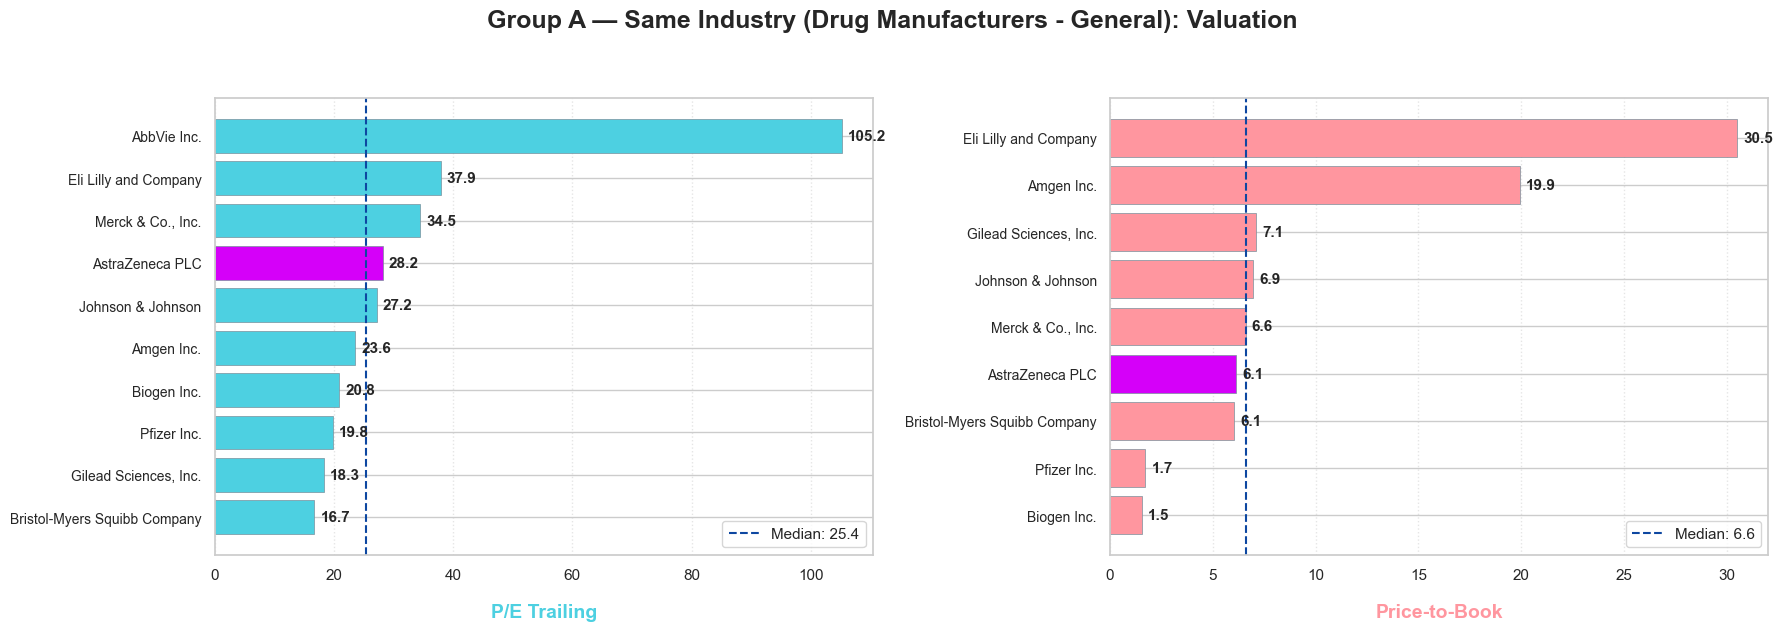

In [237]:
# =========================================================================
# STEP 4 — VALUATION ANALYSIS
# =========================================================================
# Valuation is evaluated using only Group A, as required by the assignment.
# P/E and Price-to-Book values less than or equal to zero were already set to
# NaN during data cleaning, and missing values are removed metric by metric.


def plot_valuation_group_a(data, metrics):

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor="white")

    fig.suptitle(
        "Group A — Same Industry (Drug Manufacturers - General): Valuation",
        fontsize=18,
        fontweight="bold",
        y=1.05
    )

    metric_labels = {
        "pe_trailing": "P/E Trailing",
        "price_to_book": "Price-to-Book"
    }

    peer_colors = {
        "pe_trailing": "#4DD0E1",
        "price_to_book": "#FF969F"
    }

    target_color = "#D500F9"   # The selected company is highlighted consistently.
    median_color = "#0D47A1"

    for ax, metric in zip(axes, metrics):

        # Remove missing values only for the valuation metric currently analyzed.
        # The assignment requires valuation charts to be sorted in ascending order.
        plot_data = (
            data
            .dropna(subset=[metric])
            .sort_values(metric, ascending=True)
        )

        colors = [
            target_color if symbol == target_symbol else peer_colors[metric]
            for symbol in plot_data["symbol"]
        ]

        bars = ax.barh(
            plot_data["display_name"],
            plot_data[metric],
            color=colors,
            edgecolor="#78909C",
            linewidth=0.5
        )

        # Add data labels to improve readability.
        label_offset = plot_data[metric].max() * 0.01

        for bar in bars:
            value = bar.get_width()

            ax.text(
                value + label_offset,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}",
                va="center",
                fontsize=11,
                fontweight="bold"
            )

        # The median is used as the main benchmark because valuation ratios
        # can be influenced by outliers and highly valued firms.
        median = plot_data[metric].median()

        ax.axvline(
            median,
            color=median_color,
            linestyle="--",
            linewidth=1.5,
            label=f"Median: {median:.1f}"
        )

        ax.set_xlabel(
            metric_labels[metric],
            fontsize=14,
            fontweight="bold",
            color=peer_colors[metric],
            labelpad=15
        )

        ax.grid(axis="x", linestyle=":", alpha=0.5)
        ax.tick_params(axis="y", labelsize=10)
        ax.legend(fontsize=11, loc="best")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------------
# VALUATION COMPARISON — GROUP A (SAME INDUSTRY)
# -------------------------------------------------------------------------
# The assignment requires valuation analysis using only industry peers.

plot_valuation_group_a(
    df_A,
    ["pe_trailing", "price_to_book"]
)

## Interpretation

### P/E (Price-to-Earnings Ratio): Analysis

AstraZeneca has a **P/E ratio of 28.2x**, which is slightly above the **Industry median of 25.4x**. This means that investors are willing to pay slightly more for each dollar of AstraZeneca's earnings compared with the average pharmaceutical peer.

According to the interpretative ranges, a P/E ratio above **25x** represents a **strong signal (growth premium)**. Therefore, AstraZeneca's P/E suggests that the market expects continued growth and strong future performance. Relative to its peers, AstraZeneca is positioned in the upper half of the group, although it remains below companies such as Merck, Eli Lilly and especially AbbVie, which trade at substantially higher earnings multiples.

---

### Price-to-Book: Analysis

AstraZeneca's **Price-to-Book ratio is 6.3x**, slightly below the **Industry median of 6.6x**. This indicates that the company is valued similarly to most firms in the industry. AstraZeneca is positioned close to the middle of the peer-group distribution and does not appear significantly overvalued or undervalued based on book value.

---

### Overall Valuation

Overall, AstraZeneca appears **fairly valued relative to its peers**. While its P/E ratio falls within the strong valuation range and is slightly above the industry median, its Price-to-Book ratio remains very close to the peer-group median. The company therefore receives a moderate growth premium from investors, but not to the same extent as some of the most highly valued companies in the industry.

---

### Does Valuation Reflect the Company's Fundamentals (Profit Margins & ROE)?

To assess whether AstraZeneca's valuation is justified, it is useful to compare the valuation results with the profitability analysis from Step 3.

AstraZeneca reported **profit margins of 17.2%**, above the **Industry median of 16.1%**, and a **ROE of 23.5%**, only slightly below the **Industry median of 26.4%**. These results indicate solid profitability and do not suggest weak financial performance.

Therefore, AstraZeneca's valuation does not appear to be driven by weak fundamentals. The company's profitability is broadly in line with, or slightly better than, the typical industry peer. As a result, AstraZeneca's valuation appears consistent with its underlying business performance and can be considered **fairly valued relative to its industry peers**.

##
##
##
##
##
##
## **Step 5 — Business Question 3: Is the Company Growing?**

In [234]:
# =========================================================================
# STEP 5.1 — OUTLIER CHECK FOR REVENUE GROWTH
# =========================================================================

# The assignment notes the possible presence of extreme outliers
# in revenue_growth (values > 10, corresponding to more than 1000% growth).
# We therefore inspect the maximum value observed in each peer group.

peer_groups = {
    "Group A - Industry Peers": df_A,
    "Group B - UK Peers": df_B,
    "Group C - Similar Market Cap Peers": df_C
}

max_values = []

for group_df in peer_groups.values():

    max_values.append(
        group_df["revenue_growth"].dropna().max()
    )

# =========================================================================
# CONCLUSION ON OUTLIERS
# =========================================================================

print("Maximum revenue growth values by peer group:\n")

for group_name, max_value in zip(peer_groups.keys(), max_values):

    print(
        f"{group_name}: "
        f"{max_value:.3f} ({max_value * 100:.1f}%)"
    )

print()

# Check whether the assignment's outlier threshold is exceeded
if max_value > 1000:

    print(
        "At least one revenue_growth values exceed 10 (>1000% growth). "
        "Therefore, a cap should be applied to the chart axis "
        "to avoid distortion caused by extreme outliers."
    )

else:

    print(
        "No revenue_growth values exceed 10 (>1000% growth). " 
        "Therefore, no extreme outliers were identified and no cap was applied."
    )

Maximum revenue growth values by peer group:

Group A - Industry Peers: 0.555 (55.5%)
Group B - UK Peers: 0.535 (53.5%)
Group C - Similar Market Cap Peers: 0.247 (24.7%)

No revenue_growth values exceed 10 (>1000% growth). Therefore, no extreme outliers were identified and no cap was applied.


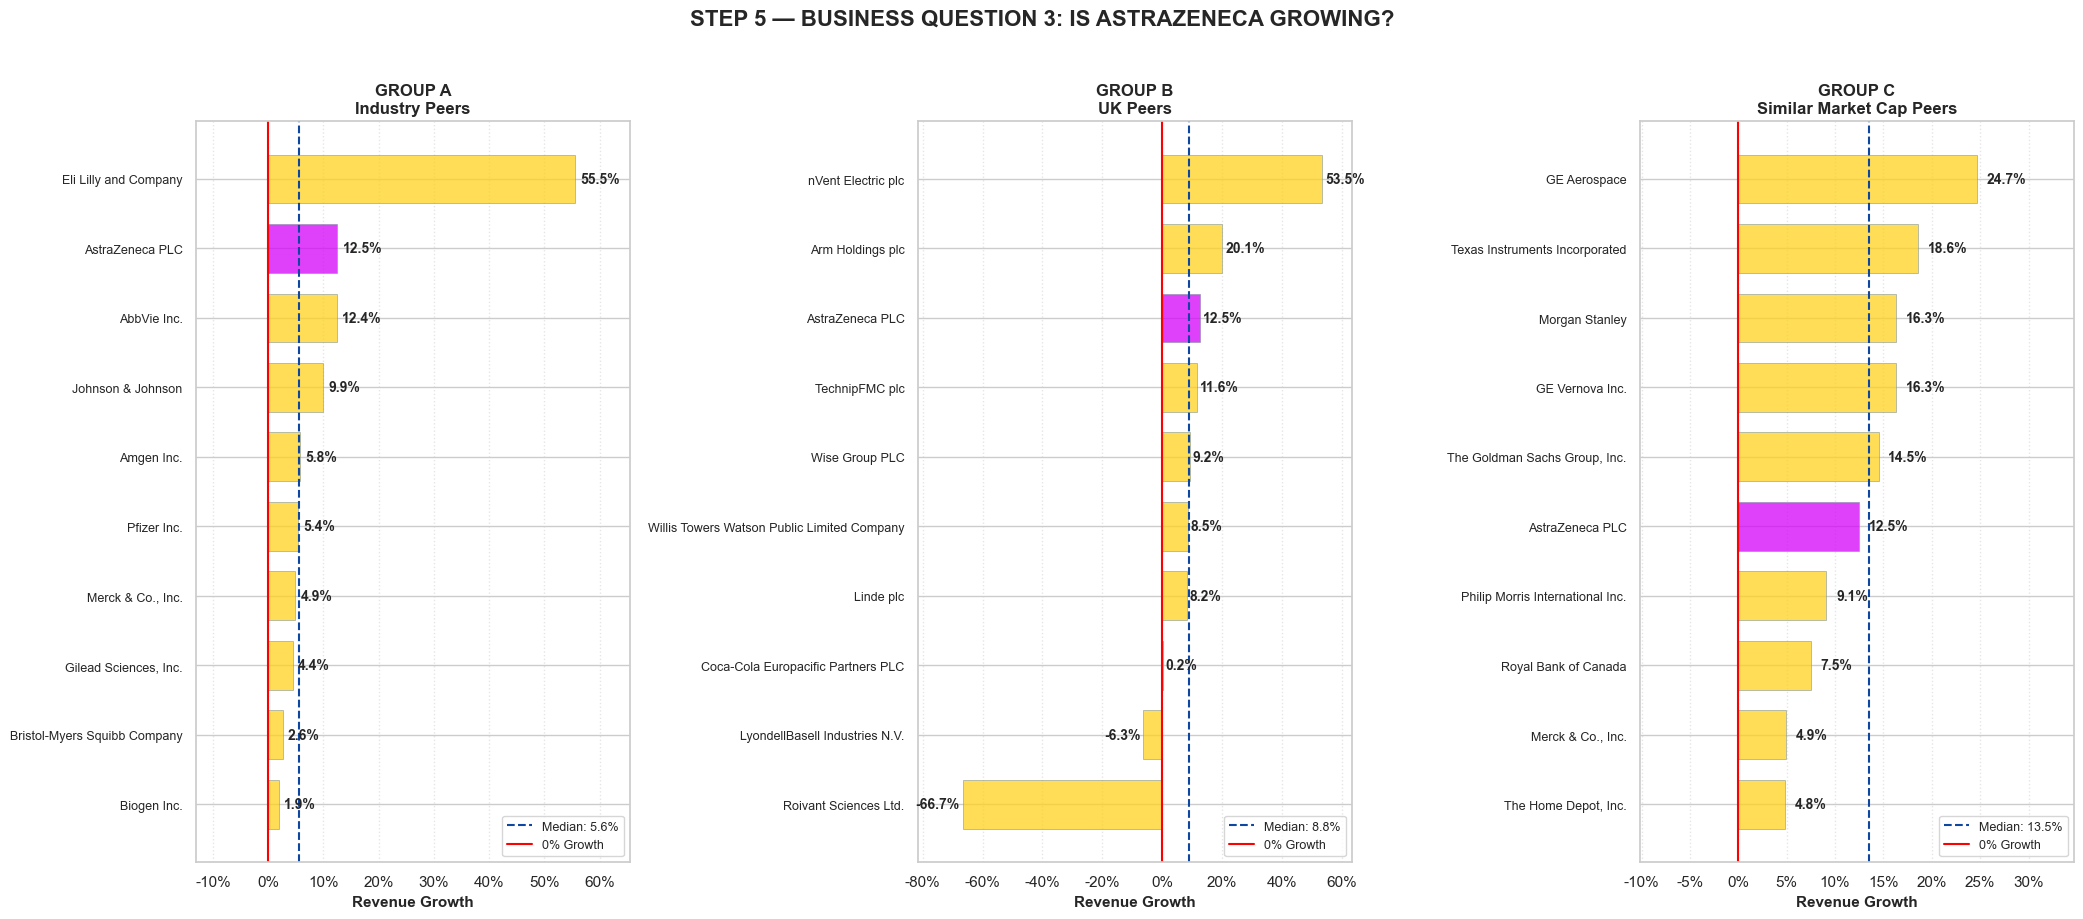

In [240]:
# =========================================================================
# STEP 5.2 — BUSINESS QUESTION 3: GROWTH
# =========================================================================
# Growth is measured using revenue_growth. As requested, the selected company
# is compared with all three peer groups and highlighted in each chart.

# Define the colors used throughout the charts
target_color = "#D500F9"      # Selected company highlighted for immediate visual benchmarking
peer_color = "#FFD21E"        # Peer companies in a neutral tone
median_color = "#0D47A1"      # Median line
zero_line_color = "red"       # Zero-growth line

# Create a figure with three side-by-side charts
fig, axes = plt.subplots(1, 3, figsize=(21, 9), facecolor="white")

fig.suptitle(
    "STEP 5 — BUSINESS QUESTION 3: IS ASTRAZENECA GROWING?",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

groups = [
    (df_A, "GROUP A\nIndustry Peers"),
    (df_B, "GROUP B\nUK Peers"),
    (df_C, "GROUP C\nSimilar Market Cap Peers")
]

for ax, (data, title) in zip(axes, groups):

    # Remove missing values only for the metric currently analyzed.
    data = data.dropna(subset=["revenue_growth"]).sort_values("revenue_growth")

    colors = [
        target_color if symbol == target_symbol else peer_color
        for symbol in data["symbol"]
    ]

    bars = ax.barh(
        data["display_name"],
        data["revenue_growth"],
        height=0.7,
        color=colors,
        edgecolor="#78909C",
        linewidth=0.5,
        alpha=0.75
    )

    # Position labels differently for positive and negative growth values.
    for bar in bars:

        value = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        if value >= 0:
            ax.text(
                value + 0.01,
                y,
                f"{value:.1%}",
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - 0.01,
                y,
                f"{value:.1%}",
                ha="right",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    # The median is preferred over the mean because growth distributions
    # often contain outliers and heavy tails.
    median = data["revenue_growth"].median()

    ax.axvline(
        median,
        color=median_color,
        linestyle="--",
        linewidth=1.5,
        label=f"Median: {median:.1%}"
    )

    ax.axvline(
        0,
        color=zero_line_color,
        linewidth=1.5,
        label="0% Growth"
    )  # Separates expanding and contracting companies

    xmin = data["revenue_growth"].min()
    xmax = data["revenue_growth"].max()

    ax.set_xlim(xmin - 0.15, xmax + 0.10)  # Extra space for labels

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.0%}")
    )  # revenue_growth is stored in decimal form (0.08 = 8%)

    ax.grid(axis="x", linestyle=":", alpha=0.5)          # Light grid for comparison
    ax.set_axisbelow(True)                               # Keep grid behind bars
    ax.set_title(title, fontsize=12, fontweight="bold") # Chart title
    ax.set_xlabel("Revenue Growth", fontsize=11, fontweight="bold")  # X-axis label
    ax.tick_params(axis="y", labelsize=9)               # Company name size
    ax.legend(fontsize=9, loc="lower right")            # Consistent legend position

plt.tight_layout()
plt.show()

## Growth Interpretation

AstraZeneca reports **revenue growth of 12.5%**, which is **above the median** of both the Industry peer group (**5.6%**) and the UK peer group (**8.8%**). Compared with companies of a similar market capitalization, AstraZeneca's growth is **slightly below the median** (**13.5%**), although the difference is small.

According to the interpretative ranges, revenue growth above **10%** represents a **strong signal**. Therefore, AstraZeneca's revenue growth can be considered strong in absolute terms, indicating that the company is expanding its revenues at a healthy rate.

Relative to its peers, AstraZeneca ranks among the strongest performers in both the Industry and UK peer groups. In the Industry group, only Eli Lilly reports substantially higher growth, while AstraZeneca outperforms most other pharmaceutical peers. In the UK peer group, AstraZeneca also grows faster than the typical company and remains well above the group median. Although growth is slightly below the median of the Similar Market Cap peer group, the difference is limited and AstraZeneca still maintains a strong growth rate.

Overall, AstraZeneca's growth profile appears **strong both in absolute terms and relative to most peer groups**. The company is not only generating positive revenue growth, but is doing so at a rate that exceeds the majority of its industry and UK peers.

The growth results also help explain the valuation observed in Step 4. AstraZeneca is growing faster than most of its industry peers, which may make investors more willing to invest in the company. Therefore, its valuation appears to be supported by its growth performance.

## **Step 6 — Business Question 4: Is the Company Financially Solid?**

In [241]:
# =========================================================================
# STEP 6.1 — OUTLIER CHECK FOR DEBT-TO-EQUITY
# =========================================================================
# The assignment notes the possible presence of extreme outliers in
# debt_to_equity (values above 10,000%).
# Since the financial strength analysis is based on Group A, the maximum
# debt-to-equity value is inspected before deciding whether an axis cap is needed.

max_debt_to_equity = (
    df_A["debt_to_equity"]
    .dropna()
    .max()
)

# =========================================================================
# CONCLUSION ON OUTLIERS
# =========================================================================

print(f"Maximum debt-to-equity value in Group A: {max_debt_to_equity:.1f}%")
print()

# Check whether the assignment's outlier threshold is exceeded.
if max_debt_to_equity > 10000:

    print(
        "At least one debt_to_equity value exceeds 10,000%. "
        "Therefore, a cap should be applied to the chart axis "
        "to avoid distortion caused by extreme outliers."
    )

else:

    print(
        "No debt_to_equity value exceeds 10,000%. "
        "Therefore, no extreme outliers were identified and no cap was applied."
    )

Maximum debt-to-equity value in Group A: 623.8%

No debt_to_equity value exceeds 10,000%. Therefore, no extreme outliers were identified and no cap was applied.


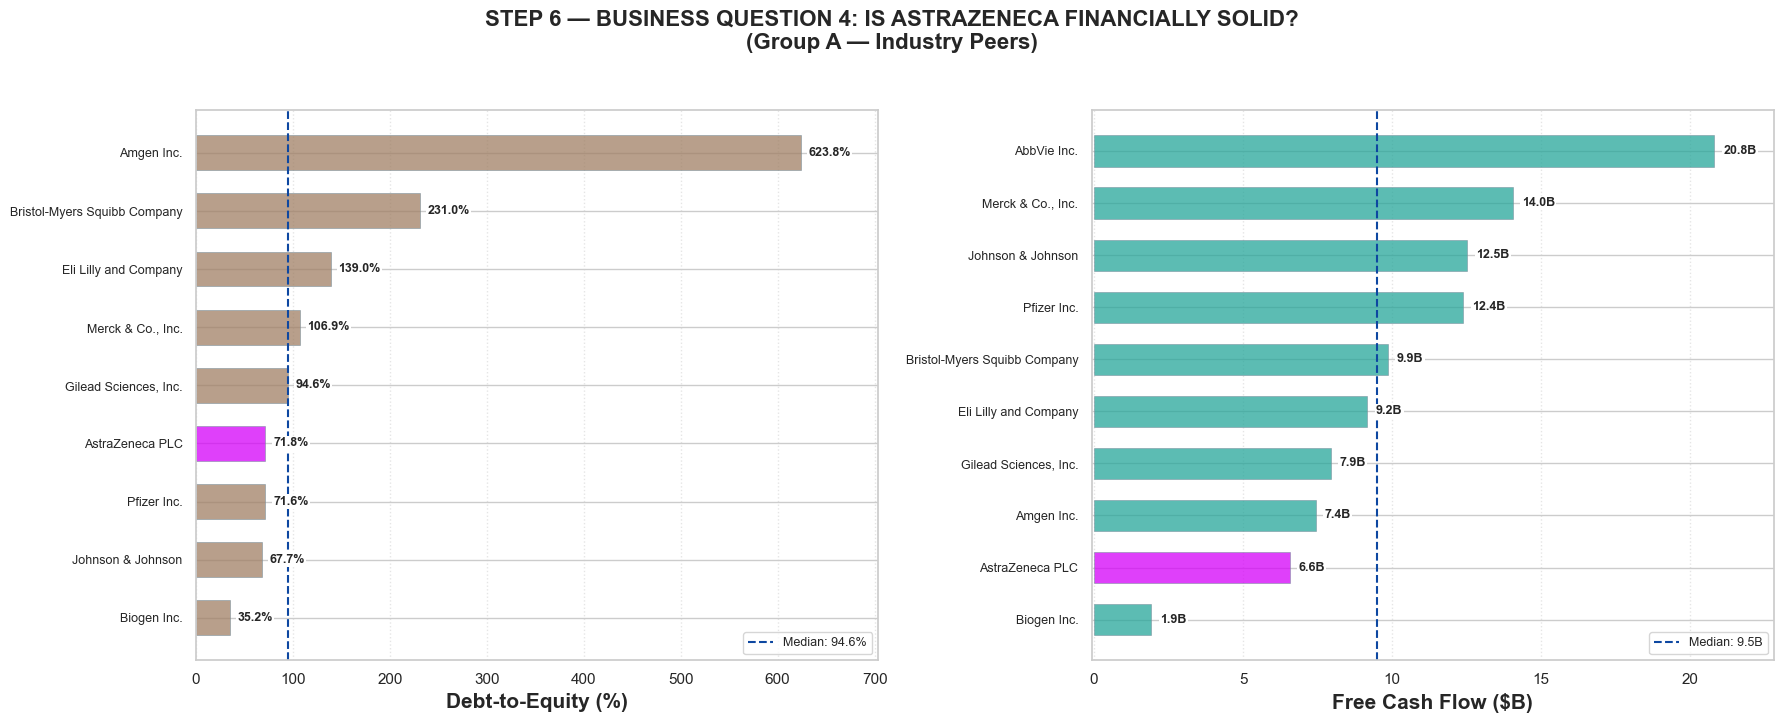

In [242]:
# =========================================================================
# STEP 6.2 — BUSINESS QUESTION 4: FINANCIAL STRENGTH
# =========================================================================
# Financial strength is evaluated using debt_to_equity and free_cashflow.
# The assignment requires this comparison to use only Group A industry peers.
# Missing values are removed separately for each metric.

df_A_debt = (
    df_A
    .dropna(subset=["debt_to_equity"])
    .sort_values("debt_to_equity")
    .copy()
)

df_A_fcf = (
    df_A
    .dropna(subset=["free_cashflow"])
    .sort_values("free_cashflow")
    .copy()
)

# free_cashflow is expressed in dollars, so it is converted to billions
# to improve chart readability.
df_A_fcf["free_cashflow_b"] = df_A_fcf["free_cashflow"] / 1_000_000_000

# Define chart colors
target_color = "#D500F9"   # Selected company highlighted consistently
median_color = "#0D47A1"

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor="white")

fig.suptitle(
    "STEP 6 — BUSINESS QUESTION 4: IS ASTRAZENECA FINANCIALLY SOLID?\n(Group A — Industry Peers)",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

# -------------------------------------------------------------------------
# DEBT-TO-EQUITY PLOT
# -------------------------------------------------------------------------
# debt_to_equity is expressed as a percentage. Lower values are generally
# preferable, although interpretation should remain relative to industry norms.

ax = axes[0]

colors_debt = [
    target_color if symbol == target_symbol else "#A07F64"
    for symbol in df_A_debt["symbol"]
]

bars = ax.barh(
    df_A_debt["display_name"],
    df_A_debt["debt_to_equity"],
    height=0.6,
    color=colors_debt,
    edgecolor="#78909C",
    linewidth=0.5,
    alpha=0.75
)

for bar in bars:

    value = bar.get_width()

    ax.text(
        value + 8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", pad=1)
    )

# The median is used as a benchmark because capital structures can vary
# considerably across firms within the same industry.
median_debt = df_A_debt["debt_to_equity"].median()

ax.axvline(
    median_debt,
    color=median_color,
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {median_debt:.1f}%"
)

ax.set_xlim(0, df_A_debt["debt_to_equity"].max() + 80)  # Extra space for labels
ax.grid(axis="x", linestyle=":", alpha=0.5)             # Light grid for comparison
ax.set_axisbelow(True)                                  # Keep grid behind bars
ax.set_xlabel("Debt-to-Equity (%)", fontsize=15, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
ax.legend(fontsize=9, loc="lower right")

# -------------------------------------------------------------------------
# FREE CASH FLOW PLOT
# -------------------------------------------------------------------------
# Positive free cash flow indicates that a company generates cash after
# capital expenditures. Higher values are generally preferable, although
# temporary negative values may reflect investment activity.

ax = axes[1]

colors_fcf = [
    target_color if symbol == target_symbol else "#26A69A"
    for symbol in df_A_fcf["symbol"]
]

bars = ax.barh(
    df_A_fcf["display_name"],
    df_A_fcf["free_cashflow_b"],
    height=0.6,
    color=colors_fcf,
    edgecolor="#78909C",
    linewidth=0.5,
    alpha=0.75
)

for bar in bars:

    value = bar.get_width()

    offset = 0.3 if value >= 0 else -0.3
    ha = "left" if value >= 0 else "right"

    ax.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}B",
        ha=ha,
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", pad=1)
    )

# The median provides a robust benchmark that is less sensitive to very
# large companies with exceptionally high cash generation.
median_fcf = df_A_fcf["free_cashflow_b"].median()

ax.axvline(
    median_fcf,
    color=median_color,
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {median_fcf:.1f}B"
)

ax.set_xlim(
    df_A_fcf["free_cashflow_b"].min() - 2,
    df_A_fcf["free_cashflow_b"].max() + 2
)  # Symmetric padding for labels

ax.grid(axis="x", linestyle=":", alpha=0.5)   # Light grid for comparison
ax.set_axisbelow(True)                        # Keep grid behind bars
ax.set_xlabel("Free Cash Flow ($B)", fontsize=15, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

## Financial Strenght Interpretation

AstraZeneca reports a **debt-to-equity ratio of 71.8%**, which is **below the Industry median (94.6%)**. This suggests that the company relies less on debt financing than the typical industry peer. According to the interpretative ranges, a debt-to-equity ratio between 50% and 200% represents an **intermediate signal**, indicating a moderate level of leverage. Therefore, AstraZeneca does not have a strong debt profile in absolute terms, but it compares favourably with most companies in its peer group.

The company also generates **positive free cash flow of $6.6B**, indicating that its operations produce cash after capital expenditures. Although AstraZeneca's free cash flow is **below the Industry median ($9.5B)**, it remains positive and therefore represents a **strong signal** according to the interpretative ranges. This suggests that the company has the ability to internally generate cash and support future investments.

Overall, AstraZeneca combines **moderate leverage with positive free cash flow generation**. While neither metric places the company among the strongest performers in the peer group, AstraZeneca's below-median debt-to-equity ratio and positive free cash flow indicate a **solid financial position**. Therefore, the company's financial profile can be considered **moderatey solid overall**, although stronger cash generation would further improve its financial strength.

# Final Summary

I selected AstraZeneca PLC (AZN) because it is one of the largest companies in the United Kingdom group and operates in the globally important pharmaceutical industry. The initial screening showed that AstraZeneca combines large market capitalization, positive profitability, solid ROE, and double-digit revenue growth, making it a suitable target company for a fundamental deep dive.

## Profitability

In terms of profitability, AstraZeneca performs well. Its net profit margin of **17.2%** is above both the Industry median (**16.1%**) and the UK median (**14.1%**), while its ROE of **23.5%** is above the UK median but below the Industry median. Overall, the profitability indicators are consistent: AstraZeneca is highly profitable and efficient. The choice to use the median rather than the mean as a benchmark was fundamental to prevent extreme performance outliers from distorting the industry baseline.

## Valuation

In terms of valuation, AstraZeneca appears fairly valued to slightly expensive. Its **P/E ratio of 28.2x** is above the Industry median (**25.4x**), suggesting a growth premium reflecting investor confidence in future earnings. However, its **Price-to-Book ratio of 6.1x** is slightly below the Industry median (**6.6x**), showing that the company does not appear extremely expensive relative to its closest industry peers. This valuation is supported by strong operational fundamentals rather than speculative market behavior.

## Growth

In terms of growth, AstraZeneca reports revenue growth of **12.5%**, which is above both the Industry and UK medians. Since revenue growth is positive and above the peer-group medians, it provides a solid economic justification for the valuation premium observed in the multiples analysis. The company therefore appears capable of expanding while already operating at a very large scale.

## Financial Strength

In terms of financial strength, AstraZeneca has a **debt-to-equity ratio of 71.8%**, which sits below the Industry median, paired with a large positive **free cash flow of $6.6B**. Although free cash flow is below the Industry median, it remains clearly robust. Therefore, leverage and cash flow metrics do not raise solvency concerns, and the company's financial profile appears solid and sustainable enough to support ongoing R&D commitments and future growth initiatives.

## Overall Assessment

Overall, AstraZeneca appears to be a financially strong company that combines profitability, growth, and solid cash generation. Although its valuation multiples suggest that investors already recognize these strengths, the company compares favorably with its peers across most of the dimensions analyzed in this project. The results indicate that AstraZeneca is well positioned within its industry and maintains a balanced combination of operational performance, growth potential, and financial stability.